In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from pathlib import Path

PROCESSED_DIR = Path("../data/processed")
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / "combined_cleaned.csv")
print(df.shape)
df.head()

(17250, 4)


,label,text,source,cleaned_text
0,0,"Go until jurong point, crazy.. Available only ...",dataset3_uci,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,dataset3_uci,ok lar joking wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,dataset3_uci,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,dataset3_uci,u dun say early hor u c already say
4,0,"Nah I don't think he goes to usf, he lives aro...",dataset3_uci,nah think go usf life around though


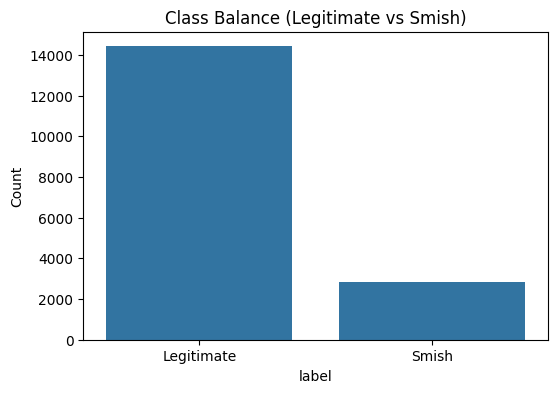

In [7]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="label")
plt.xticks([0, 1], ["Legitimate", "Smish"])
plt.title("Class Balance (Legitimate vs Smish)")
plt.ylabel("Count")
plt.savefig(FIGURES_DIR / "class_balance.png", dpi=150, bbox_inches="tight")
plt.show()

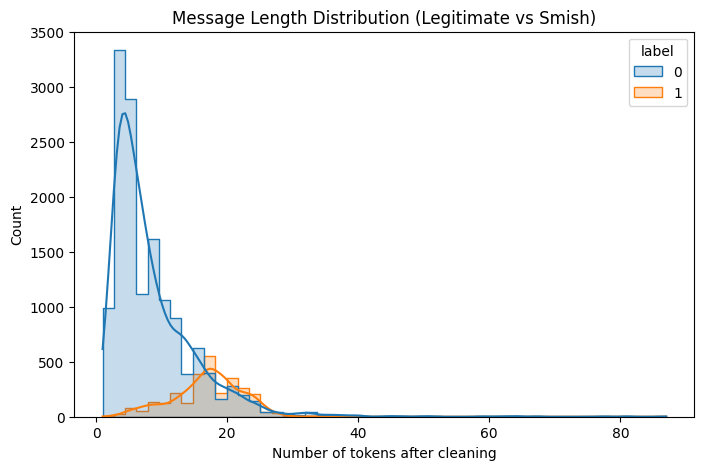

         count       mean       std  min   25%   50%   75%   max
label                                                           
0      14414.0   8.505828  6.698350  1.0   4.0   6.0  11.0  87.0
1       2836.0  17.053949  5.209703  2.0  14.0  17.0  20.0  38.0


In [8]:
df["text_length"] = df["cleaned_text"].str.split().apply(len)

plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="text_length", hue="label", bins=50, kde=True, element="step")
plt.title("Message Length Distribution (Legitimate vs Smish)")
plt.xlabel("Number of tokens after cleaning")
plt.savefig(FIGURES_DIR / "length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(df.groupby("label")["text_length"].describe())

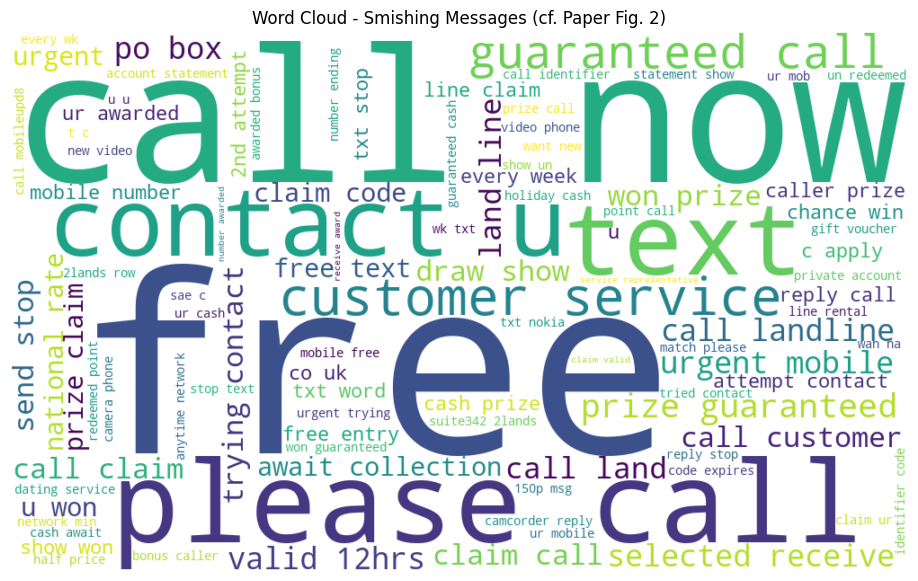

In [9]:
smish_text = " ".join(df[df["label"] == 1]["cleaned_text"])

wc = WordCloud(
    width=1000, height=600,
    background_color="white",
    max_words=100,
    colormap="viridis"
).generate(smish_text)

plt.figure(figsize=(12, 7))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud - Smishing Messages (cf. Paper Fig. 2)")
plt.savefig(FIGURES_DIR / "wordcloud_smish.png", dpi=150, bbox_inches="tight")
plt.show()